# 배터리 시장 전략 분석 에이전트 — 그래프 시각화

현재 정의된 LangGraph 구조를 확인합니다.

**메인 그래프 흐름**
```
START
  ↓
retrieve (공통 RAG 검색)
  ↓ Send API (병렬)
┌─────────────────────┐  ┌─────────────────────┐
│ company_analysis     │  │ company_analysis     │
│ [LG에너지솔루션]      │  │ [CATL]               │
│ (Supervisor)         │  │ (Supervisor)         │
└──────────┬──────────┘  └──────────┬──────────┘
           └──────────┬─────────────┘
                      ↓
           company_comparison
                      ↓
           report_generation
                      ↓
                     END
```

**서브그래프**
- `company_supervisor` : market_analysis → tech_analysis → swot_analysis 조율
- `swot_subgraph` : gather_info → classify_swot → format_matrix
- `report_generation` : generate_sections → validate_references → render_html → convert_pdf

## 1. 경로 설정

In [1]:
import sys
import os

# 프로젝트 루트를 경로에 추가
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# WeasyPrint가 Homebrew libgobject를 찾을 수 있도록 설정 (run.sh와 동일)
os.environ["DYLD_LIBRARY_PATH"] = "/opt/homebrew/lib:" + os.environ.get("DYLD_LIBRARY_PATH", "")

print(f"프로젝트 루트: {project_root}")
print(f"DYLD_LIBRARY_PATH: {os.environ['DYLD_LIBRARY_PATH']}")

프로젝트 루트: /Users/bae/Workspace/solo-agent
DYLD_LIBRARY_PATH: /opt/homebrew/lib:


## 2. 그래프 빌드

In [2]:
from battery_market_agent.agents import build_graph

graph = build_graph()
print("메인 그래프 빌드 완료")

USER_AGENT environment variable not set, consider setting it to identify your requests.


메인 그래프 빌드 완료


## 3. Mermaid 다이어그램 출력

In [3]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	company_analysis(company_analysis)
	company_comparison(company_comparison)
	report_generation(report_generation)
	__end__([<p>__end__</p>]):::last
	__start__ --> retrieve;
	company_analysis --> company_comparison;
	company_comparison --> report_generation;
	retrieve -.-> company_analysis;
	report_generation --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 4. 그래프 이미지 렌더링

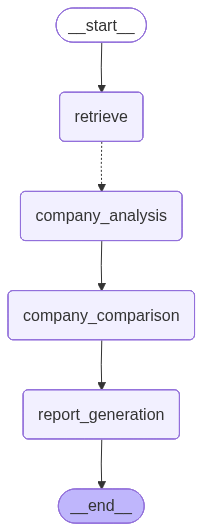

In [4]:
from IPython.display import Image, display

image_bytes = graph.get_graph().draw_mermaid_png()
display(Image(image_bytes))

## 5. 노드 및 엣지 상세 정보

In [5]:
g = graph.get_graph()

print("=== 노드 ===")
for node in g.nodes:
    print(f"  - {node}")

print("\n=== 엣지 ===")
for edge in g.edges:
    print(f"  {edge.source} → {edge.target}")

=== 노드 ===
  - __start__
  - retrieve
  - company_analysis
  - company_comparison
  - report_generation
  - __end__

=== 엣지 ===
  __start__ → retrieve
  company_analysis → company_comparison
  company_comparison → report_generation
  retrieve → company_analysis
  report_generation → __end__


## 6. company_supervisor 서브그래프 (market / tech / swot 에이전트 조율)

In [6]:
from battery_market_agent.agents.company_analysis_agent import company_supervisor

print("=== company_supervisor Mermaid ===")
print(company_supervisor.get_graph(xray=True).draw_mermaid())

=== company_supervisor Mermaid ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor\3a__start__;
	market_analysis_agent\3a__end__ --> supervisor\3a__start__;
	supervisor\3a__end__ -.-> __end__;
	supervisor\3a__end__ -.-> market_analysis_agent\3a__start__;
	supervisor\3a__end__ -.-> swot_analysis_agent\3a__start__;
	supervisor\3a__end__ -.-> tech_analysis_agent\3a__start__;
	swot_analysis_agent\3a__end__ --> supervisor\3a__start__;
	tech_analysis_agent\3a__end__ --> supervisor\3a__start__;
	subgraph supervisor
	supervisor\3a__start__(<p>__start__</p>)
	supervisor\3aagent(agent)
	supervisor\3atools(tools)
	supervisor\3a__end__(<p>__end__</p>)
	supervisor\3a__start__ --> supervisor\3aagent;
	supervisor\3aagent -.-> supervisor\3a__end__;
	supervisor\3aagent -.-> supervisor\3atools;
	supervisor\3atools --> supervisor\3aagent;
	end
	subgraph market_analysis_agent
	market_analysis_agent\

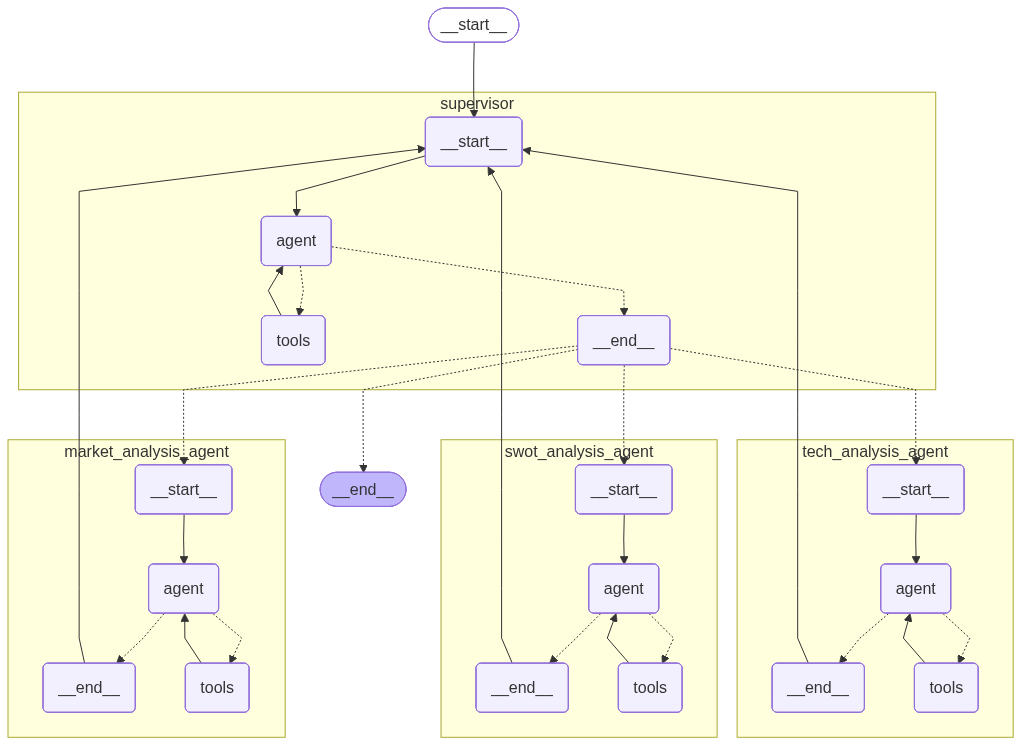

In [7]:
display(Image(company_supervisor.get_graph(xray=True).draw_mermaid_png()))

## 7. SWOT 서브그래프 (gather_info → classify_swot → format_matrix)

=== swot_subgraph Mermaid ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	gather_info(gather_info)
	classify_swot(classify_swot)
	format_matrix(format_matrix)
	__end__([<p>__end__</p>]):::last
	__start__ --> gather_info;
	classify_swot --> format_matrix;
	gather_info --> classify_swot;
	format_matrix --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



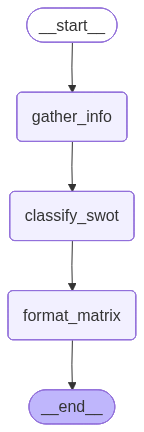

In [8]:
from battery_market_agent.agents.swot import swot_subgraph

print("=== swot_subgraph Mermaid ===")
print(swot_subgraph.get_graph().draw_mermaid())
display(Image(swot_subgraph.get_graph().draw_mermaid_png()))

## 8. report_generation 서브그래프 (generate_sections → validate_references → render_html → convert_pdf)

=== report_generation 서브그래프 Mermaid ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate_sections(generate_sections)
	validate_references(validate_references)
	render_html(render_html)
	convert_pdf(convert_pdf)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate_sections;
	generate_sections --> validate_references;
	render_html --> convert_pdf;
	validate_references --> render_html;
	convert_pdf --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



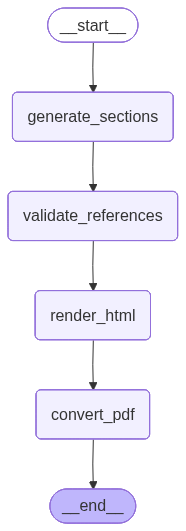

In [9]:
from battery_market_agent.agents.report_generation_agent import _report_graph

print("=== report_generation 서브그래프 Mermaid ===")
print(_report_graph.get_graph().draw_mermaid())
display(Image(_report_graph.get_graph().draw_mermaid_png()))

## 9. 메인 그래프 전체 확장 시각화 (xray=True)

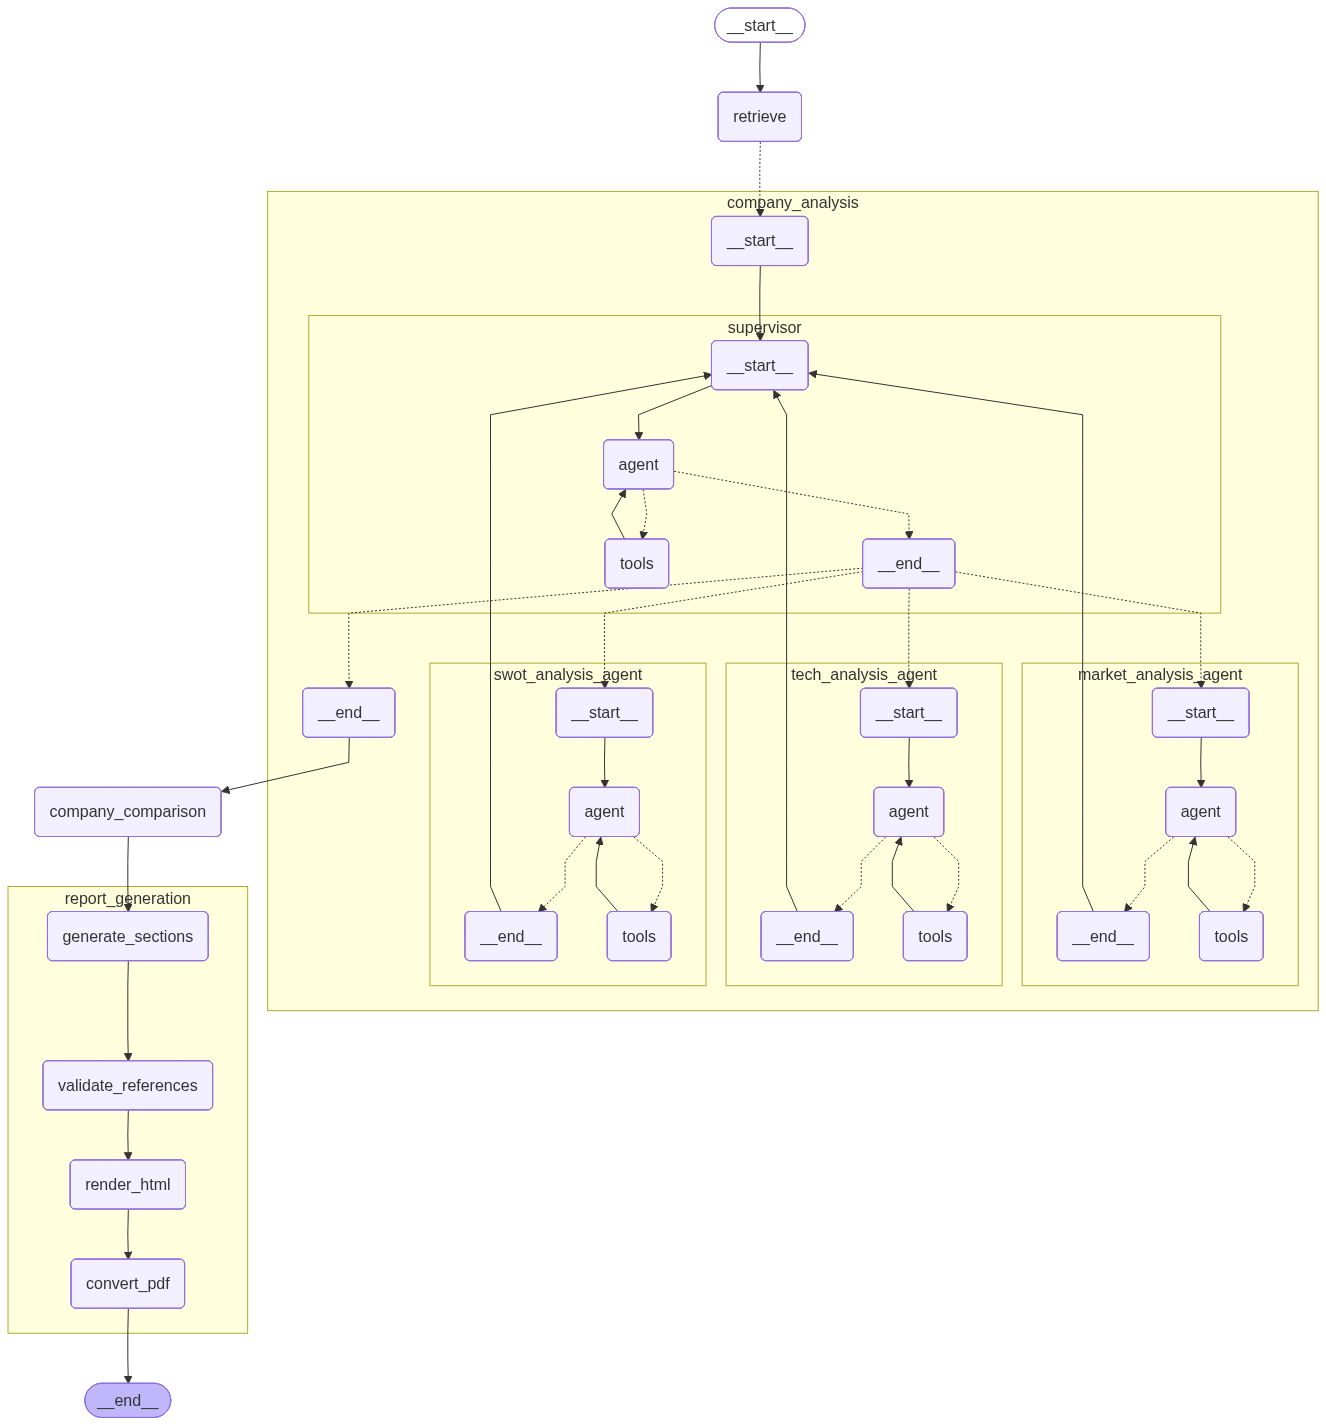

In [10]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))